Unit tests for specified levels of sensor quality

In [46]:
from shipClass.Sensor_basic import Sensor
import numpy as np

sensor = Sensor(quality=0.90)

print("Observation Probabilities: \n", sensor.observation_probs)

true_states = np.random.choice([0, 1, 2], size=25, p=[0.6, 0.3, 0.1])
sensor.read(true_states)

print("True states:   ", true_states)
print("Sensor reads:  ", sensor.sensedHistory)
print("Was correct?:  ", sensor.history, f"({(sum(sensor.history)/ len(sensor.history))*100} %)")

Observation Probabilities: 
 [[0.9  0.05 0.05]
 [0.05 0.9  0.05]
 [0.05 0.05 0.9 ]]
True states:    [1 0 1 0 2 1 0 1 0 1 0 2 0 0 0 0 2 1 0 0 0 1 1 1 0]
Sensor reads:   [1 0 2 0 2 1 0 0 0 1 0 2 0 0 0 0 2 1 0 0 0 0 1 1 1]
Was correct?:   [1 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0] (84.0 %)


Hidden Markov Model Belief Update (single sensor)

     t true_state sensor_reading est_state    P(Healthy)   P(Degraded)  \
15  15     Failed         Failed    Failed  6.473341e-11  1.922053e-03   
16  16     Failed         Failed    Failed  1.479804e-12  2.128958e-04   
17  17     Failed       Degraded    Failed  1.146836e-12  1.498966e-03   
18  18     Failed       Degraded    Failed  8.818680e-13  1.047180e-02   
19  19     Failed         Failed    Failed  2.030369e-14  1.168204e-03   
20  20     Failed         Failed    Failed  4.638512e-16  1.293150e-04   
21  21     Failed         Failed    Failed  1.058786e-17  1.430225e-05   
22  22     Failed         Failed    Failed  2.416552e-19  1.581679e-06   
23  23     Failed         Failed    Failed  5.515431e-21  1.749153e-07   
24  24     Failed         Failed    Failed  1.258816e-22  1.934358e-08   

    P(Failed)  
15   0.998078  
16   0.999787  
17   0.998501  
18   0.989528  
19   0.998832  
20   0.999871  
21   0.999986  
22   0.999998  
23   1.000000  
24   1.000000  


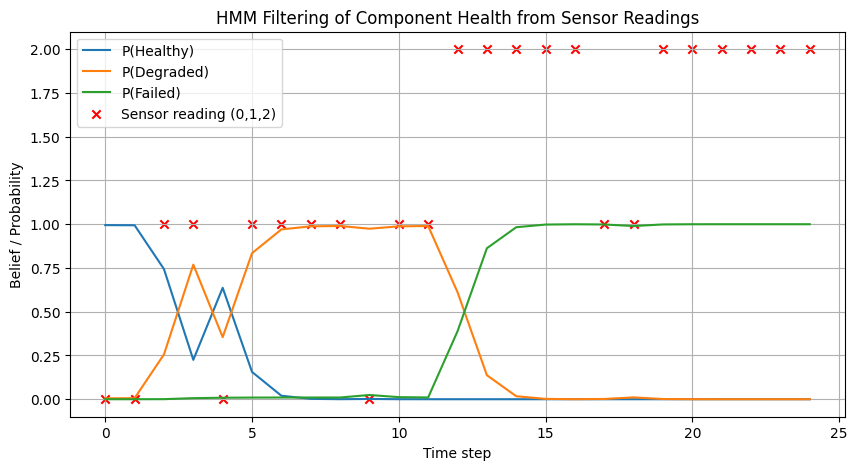

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- Define model ---
# State labels: 0 = Healthy, 1 = Degraded, 2 = Failed
states = ["Healthy", "Degraded", "Failed"]

# Transition matrix (based on approximate MTTF, assuming irreversible degradation)
P = np.array([
    [0.97, 0.03, 0.00],   # Healthy → Degraded
    [0.00, 0.94, 0.06],   # Degraded → Failed
    [0.00, 0.00, 1.00]    # Failed is absorbing
])

# Sensor confusion matrix (rows = true state, cols = reading)
O = np.array([
    [0.90, 0.08, 0.02],
    [0.15, 0.75, 0.10],
    [0.05, 0.10, 0.85]
])

# --- Simulate true states and sensor readings ---
n_steps = 25
true_states = np.zeros(n_steps, dtype=int)
for t in range(1, n_steps):
    true_states[t] = np.random.choice([0,1,2], p=P[true_states[t-1]])

# Generate sensor readings
sensor_readings = np.zeros(n_steps, dtype=int)
for t in range(n_steps):
    sensor_readings[t] = np.random.choice([0,1,2], p=O[true_states[t]])

# --- HMM Forward Filter ---
def hmm_filter(P, O, observations):
    n_states = P.shape[0]
    T = len(observations)
    belief = np.array([1.0, 0.0, 0.0])  # start fully Healthy
    beliefs = np.zeros((T, n_states))
    for t, z in enumerate(observations):
        # Predict step
        belief = belief @ P
        # Update step (elementwise multiply by emission probability)
        belief = belief * O[:, z]
        # Normalize
        belief = belief / belief.sum()
        beliefs[t] = belief
    return beliefs

beliefs = hmm_filter(P, O, sensor_readings)

# --- Most likely state at each step ---
estimated_states = beliefs.argmax(axis=1)

# --- Display results ---
df = pd.DataFrame({
    "t": np.arange(n_steps),
    "true_state": [states[i] for i in true_states],
    "sensor_reading": [states[i] for i in sensor_readings],
    "est_state": [states[i] for i in estimated_states],
    "P(Healthy)": beliefs[:,0],
    "P(Degraded)": beliefs[:,1],
    "P(Failed)": beliefs[:,2]
})
print(df.tail(10))

# --- Plot belief evolution ---
plt.figure(figsize=(10,5))
plt.plot(beliefs[:,0], label="P(Healthy)")
plt.plot(beliefs[:,1], label="P(Degraded)")
plt.plot(beliefs[:,2], label="P(Failed)")
plt.scatter(np.arange(n_steps), sensor_readings, c='r', marker='x', label="Sensor reading (0,1,2)")
plt.xlabel("Time step")
plt.ylabel("Belief / Probability")
plt.title("HMM Filtering of Component Health from Sensor Readings")
plt.legend()
plt.grid(True)
plt.show()

HMM Belief Updating Filter ( Multi-Sensor)

[2 2 2 2 2 1 1 1 1 1]
[2 1 2 2 1 1 1 1 1 1]
[ True False  True  True False  True  True  True  True  True]
accuracy := 0.8


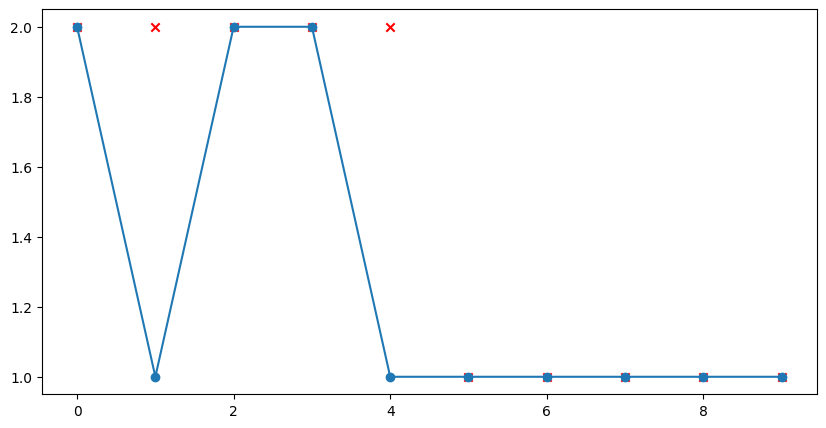

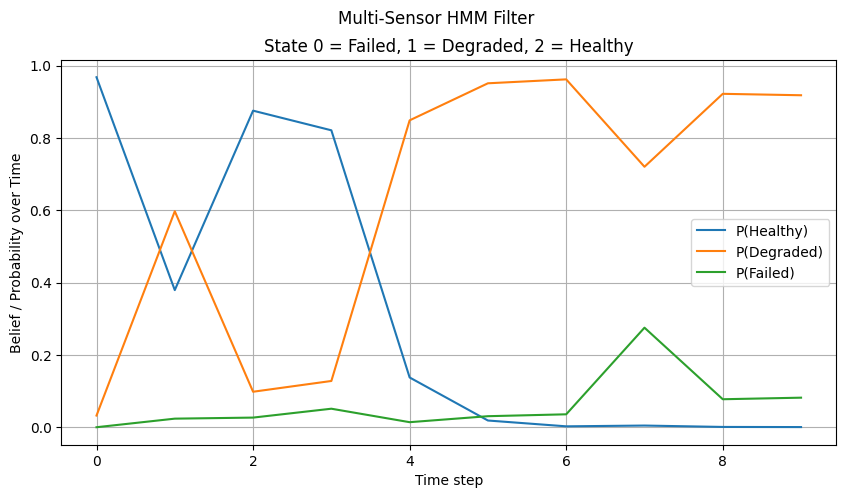

In [87]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- Define state labels ---
# Now 0 = Failed, 1 = Degraded, 2 = Healthy
states = ["Failed", "Degraded", "Healthy"]
n_states = len(states)
n_steps = 10
n_sensors = 3

# --- Transition matrix ---
# Rows sum to 1, row i = current state, col j = next state
# Healthy (2) → Degraded (1) → Failed (0)
P = np.array([
    [1.00, 0.00, 0.00],   # Failed stays failed
    [0.25, 0.75, 0.00],   # Degraded may fail
    [0.00, 0.50, 0.50]    # Healthy may degrade
])

# --- Observation matrices (for 3 sensors) ---
# Each row: true state, each col: sensor reading (0=Fail,1=Degraded,2=Healthy)
O_list = [
    np.array([[0.75, 0.15, 0.10],   # Sensor 1
              [0.15, 0.75, 0.10],
              [0.10, 0.15, 0.75]]),

    np.array([[0.5, 0.25, 0.25],   # Sensor 2
              [0.25, 0.5, 0.25],
              [0.25, 0.25, 0.50]]),

    np.array([[0.5, 0.25, 0.25],   # Sensor 3
              [0.25, 0.5, 0.25],
              [0.25, 0.25, 0.50]])
]

# --- Simulate true state sequence ---
true_states = np.zeros(n_steps, dtype=int)
true_states[0] = 2  # start Healthy
for t in range(1, n_steps):
    true_states[t] = np.random.choice([0, 1, 2], p=P[true_states[t-1]])

# --- Simulate multi-sensor readings ---
sensor_readings = np.zeros((n_steps, n_sensors), dtype=int)
for t in range(n_steps):
    for i in range(n_sensors):
        sensor_readings[t, i] = np.random.choice([0, 1, 2], p=O_list[i][true_states[t]])

# --- HMM filter for multiple sensors ---
def hmm_multisensor_filter(P, O_list, all_observations, init_state=2):
    n_states = P.shape[0]
    T = len(all_observations)
    belief = np.zeros(n_states)
    belief[init_state] = 1.0    # start fully Healthy with 100% certainty
    beliefs = np.zeros((T, n_states))

    for t in range(T):
        # Predict step
        belief = belief @ P      # spread belief based on transition probabilities 
        # Update step — multiply all sensor likelihoods
        obs = all_observations[t]
        likelihood = np.ones(n_states)
        for i, O in enumerate(O_list):
            likelihood *= O[:, obs[i]]
        belief *= likelihood
        # Normalize
        belief /= belief.sum()
        beliefs[t] = belief
    return beliefs

beliefs = hmm_multisensor_filter(P, O_list, sensor_readings, init_state=2)
estimated_states = beliefs.argmax(axis=1)

# # --- Summarize ---
# df = pd.DataFrame({
#     "t": np.arange(n_steps),
#     "true_state": [states[i] for i in true_states],
#     "sensor_1": [states[i] for i in sensor_readings[:,0]],
#     "sensor_2": [states[i] for i in sensor_readings[:,1]],
#     "sensor_3": [states[i] for i in sensor_readings[:,2]],
#     "est_state": [states[i] for i in estimated_states],
#     "P(Failed)": beliefs[:,0],
#     "P(Degraded)": beliefs[:,1],
#     "P(Healthy)": beliefs[:,2]
# })

# print(df.head(25))

# --- Plot results ---
# truth vs estimated
print(true_states)
print(estimated_states)
print(estimated_states==true_states.reshape(-1))
print("accuracy :=", np.sum(true_states == estimated_states) / n_steps)

plt.figure(figsize=(10,5))
plt.scatter(np.arange(n_steps), true_states, c='r', marker='x', label="true states")
plt.plot(np.arange(n_steps), estimated_states, label="estimated states", marker='o')


plt.figure(figsize=(10,5))
plt.plot(beliefs[:,2], label="P(Healthy)")
plt.plot(beliefs[:,1], label="P(Degraded)")
plt.plot(beliefs[:,0], label="P(Failed)")
plt.xlabel("Time step")
plt.ylabel("Belief / Probability over Time")
plt.suptitle("Multi-Sensor HMM Filter") 
plt.title("State 0 = Failed, 1 = Degraded, 2 = Healthy")
plt.legend()
plt.grid(True)
plt.show()

RUL prediction from belief

=== RUL Summary ===
Expected RUL (mean):  6.89 steps
Median RUL:           31 steps
Probability of failure within 10 steps: 15.41%
Probability of surviving 20 steps:      69.02%

    time_to_failure       pmf       cdf  survival
0                 0  0.020000  0.020000  0.980000
1                 1  0.010800  0.030800  0.969200
2                 2  0.011592  0.042392  0.957608
3                 3  0.012293  0.054685  0.945315
4                 4  0.012911  0.067596  0.932404
5                 5  0.013450  0.081046  0.918954
6                 6  0.013918  0.094964  0.905036
7                 7  0.014320  0.109284  0.890716
8                 8  0.014660  0.123943  0.876057
9                 9  0.014944  0.138887  0.861113
10               10  0.015176  0.154063  0.845937
11               11  0.015360  0.169423  0.830577
12               12  0.015500  0.184923  0.815077
13               13  0.015600  0.200523  0.799477
14               14  0.015663  0.216186  0.783814


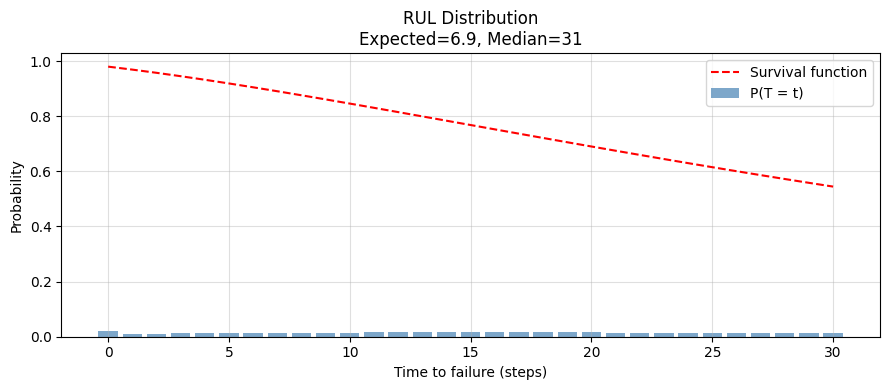

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- Example transition matrix ---
# 0 = Healthy, 1 = Degraded, 2 = Failed (absorbing)
P = np.array([
    [0.97, 0.03, 0.00],   # Healthy → Degraded
    [0.00, 0.94, 0.06],   # Degraded → Failed
    [0.00, 0.00, 1.00]    # Failed absorbs
])

# --- Example current belief (from HMM filter posterior) ---
# say the filter thinks the component is mostly healthy
b0 = np.array([0.80, 0.18, 0.02])

fail_idx = 2  # index of "failed" state

# --- Function: compute RUL distribution ---
def rul_distribution_from_belief(P, b0, fail_idx, horizon=50):
    """
    Compute discrete probability mass function (pmf) of time to failure
    given current belief b0 and transition matrix P.
    pmf[k] = P(T = k), where T = first hitting time of failure.
    """
    n = P.shape[0]
    pmf = np.zeros(horizon + 1)
    # already failed
    pmf[0] = b0[fail_idx]
    # probability still alive (transient part)
    b_trans = b0.copy()
    b_trans[fail_idx] = 0.0

    for k in range(1, horizon + 1):
        # probability of failure at next step
        prob_to_fail = np.sum(b_trans * P[:, fail_idx])
        pmf[k] = prob_to_fail
        # advance transient distribution
        b_trans = b_trans @ P
        b_trans[fail_idx] = 0.0
    return pmf

# --- Compute PMF and derived metrics ---
pmf = rul_distribution_from_belief(P, b0, fail_idx, horizon=30)
times = np.arange(len(pmf))
cdf = np.cumsum(pmf)
survival = 1 - cdf

# Expected RUL
expected_rul = np.sum(times * pmf)
median_rul = np.searchsorted(cdf, 0.5)

# --- Print summary ---
print("=== RUL Summary ===")
print(f"Expected RUL (mean):  {expected_rul:.2f} steps")
print(f"Median RUL:           {median_rul} steps")
print(f"Probability of failure within 10 steps: {cdf[10]:.2%}")
print(f"Probability of surviving 20 steps:      {survival[20]:.2%}\n")

# --- Optional: show PMF table ---
df = pd.DataFrame({
    "time_to_failure": times,
    "pmf": pmf,
    "cdf": cdf,
    "survival": survival
})
print(df.head(15))

# --- Plot results ---
plt.figure(figsize=(9,4))
plt.bar(times, pmf, color='steelblue', alpha=0.7, label='P(T = t)')
plt.plot(times, survival, 'r--', label='Survival function')
plt.xlabel("Time to failure (steps)")
plt.ylabel("Probability")
plt.title(f"RUL Distribution\nExpected={expected_rul:.1f}, Median={median_rul}")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


Replacing sensor aggregations (mode) with a Kalman filter

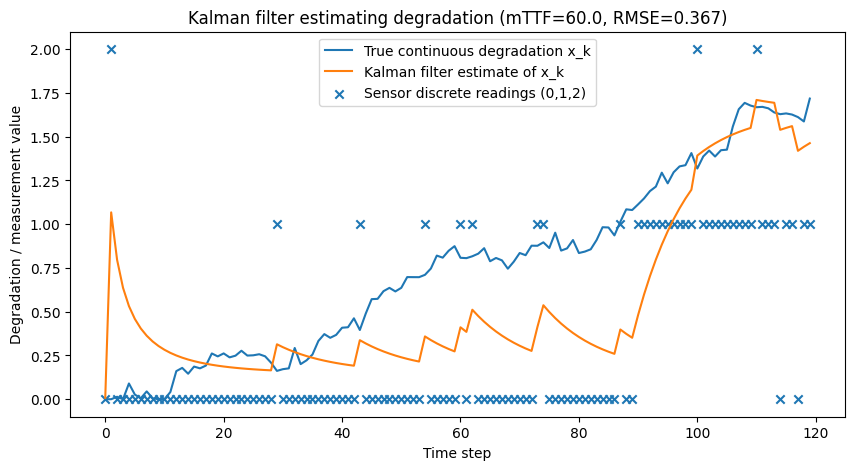

ModuleNotFoundError: No module named 'caas_jupyter_tools'

In [47]:
# Simulate a degradation process with a noisy discrete sensor, then apply a Kalman Filter
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(2)

class Sensor:
    def __init__(self, observation_probs):
        # observation_probs: rows = true discrete state (0,1,2), cols = P(read 0,1,2)
        self.observation_probs = np.array(observation_probs)
        self.sensedHistory = np.array([], dtype=int)
        self.history = np.array([], dtype=int)
    
    def read(self, true_history):
        n = len(true_history)
        sensed = np.full(n, -1, dtype=int)
        for state in range(self.observation_probs.shape[0]):
            mask = (true_history == state)
            if mask.any():
                sensed[mask] = np.random.choice(
                    [0, 1, 2],
                    size=mask.sum(),
                    p=self.observation_probs[state]
                )
        if (sensed == -1).any():
            raise RuntimeError("Sensor.read: some sensed entries were not assigned. "
                               f"true_history={true_history}, sensed={sensed}")
        working = (sensed == true_history).astype(int)
        self.sensedHistory = np.concatenate([self.sensedHistory, sensed])
        self.history = np.concatenate([self.history, working])
        return sensed, working

# Kalman filter for a scalar state x
class SimpleKF:
    def __init__(self, F=1.0, H=1.0, Q=0.01, R=1.0, x0=0.0, P0=1.0):
        self.F = F   # state transition (scalar)
        self.H = H   # measurement matrix (scalar)
        self.Q = Q   # process noise variance
        self.R = R   # measurement noise variance
        self.x = x0  # state estimate
        self.P = P0  # estimate covariance
        
    def predict(self, control=0.0):
        # simple model x_{k+1} = F*x_k + control + w
        self.x = self.F * self.x + control
        self.P = self.F * self.P * self.F + self.Q
        return self.x, self.P
    
    def update(self, z):
        # measurement z = H*x + v
        S = self.H * self.P * self.H + self.R
        K = (self.P * self.H) / S
        self.x = self.x + K * (z - self.H * self.x)
        self.P = (1 - K * self.H) * self.P
        return self.x, self.P, K

# --- Simulation parameters ---
timesteps = 120
mTTF = 60.0    # mean time to failure (in same time units as timesteps)
lam = 1.0 / mTTF  # constant hazard / average per-step increase in cumulative hazard

Q_true = 0.002   # true process noise variance (for simulating x)
Q_kf = 0.01      # KF assumed process variance
R_kf = 0.4       # KF assumed measurement variance (we'll be observing quantized sensor outputs)

x_fail = 3.0     # scaling: when x reaches x_fail, we'll treat the true discrete state as "failed" (2)
# thresholds for discrete states: [0, x_fail/3) -> 0, [x_fail/3, 2x_fail/3) ->1, [2x_fail/3, x_fail] -> 2
thresholds = [x_fail/3, 2*x_fail/3]

# sensor confusion matrix (rows: true state 0,1,2 -> columns: Pr(read 0,1,2))
observation_probs = [
    [0.90, 0.08, 0.02],
    [0.15, 0.75, 0.10],
    [0.05, 0.10, 0.85]
]

sensor = Sensor(observation_probs)

# Simulate true continuous degradation x_k (cumulative hazard-like)
true_x = np.zeros(timesteps)
for k in range(1, timesteps):
    true_x[k] = true_x[k-1] + lam + np.random.normal(0, np.sqrt(Q_true))
    # clip so state doesn't go negative
    if true_x[k] < 0:
        true_x[k] = 0.0

# Map continuous x to true discrete states (0,1,2)
true_states = np.digitize(true_x, bins=thresholds)

# Get sensor readings using the provided sensor model
sensed, working = sensor.read(true_states)

# For Kalman filtering, we need numeric measurements. We will use the sensor's discrete readings (0,1,2)
# and assume a linear relationship z = H * x + v where H maps x in [0, x_fail] to [0,2].
H = 2.0 / x_fail

kf = SimpleKF(F=1.0, H=H, Q=Q_kf, R=R_kf, x0=0.0, P0=1.0)

estimates = np.zeros(timesteps)
P_vals = np.zeros(timesteps)
Ks = np.zeros(timesteps)

for k in range(timesteps):
    # Predict step: include expected drift lam as a control term (we'll add it after the predict)
    kf.predict(control=lam)
    # update with measurement z = sensed[k] (treated as numeric)
    x_upd, P_upd, K = kf.update(z=float(sensed[k]))
    estimates[k] = x_upd
    P_vals[k] = P_upd
    Ks[k] = K

# Compute RMSE between scaled true_x and estimates (they're comparable because H maps x-> [0,2])
rmse = np.sqrt(np.mean((estimates - true_x)**2))

# Plot results
plt.figure(figsize=(10, 5))
plt.plot(true_x, label="True continuous degradation x_k")
plt.plot(estimates, label="Kalman filter estimate of x_k")
plt.scatter(np.arange(timesteps), sensed, marker='x', label="Sensor discrete readings (0,1,2)")
plt.legend()
plt.xlabel("Time step")
plt.ylabel("Degradation / measurement value")
plt.title(f"Kalman filter estimating degradation (mTTF={mTTF}, RMSE={rmse:.3f})")
plt.show()

# Also show a small table of last values
import pandas as pd
df = pd.DataFrame({
    "t": np.arange(timesteps),
    "true_x": true_x,
    "true_state": true_states,
    "sensed": sensed,
    "kf_estimate": estimates,
    "kf_P": P_vals,
    "kf_K": Ks
})
df_tail = df.tail(10)
import caas_jupyter_tools as tools; tools.display_dataframe_to_user("KF simulation last rows", df_tail)

# Print some diagnostics
print(f"Final RMSE (true_x vs estimate): {rmse:.4f}")
print("Sensor confusion matrix (rows=true state, cols=P(read 0/1/2)):\n", np.array(observation_probs))
